In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [36]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features"
    / "provider_features_v2.csv"
)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\Users\Admin\Downloads\CTS_hackathon_demo\CTS_hackathon_demo
Dataset path: c:\Users\Admin\Downloads\CTS_hackathon_demo\CTS_hackathon_demo\data\processed\features\provider_features_v2.csv
Dataset exists: True


In [37]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (5410, 32)


,Provider,Unique_Beneficiaries,Avg_Patient_Age,Avg_Chronic_Conditions,IP_Claim_Count,IP_Unique_Beneficiaries,IP_Total_Reimbursement,IP_Avg_Reimbursement,IP_Max_Reimbursement,IP_Total_Deductible,...,Total_Claims,Total_Reimbursement,Total_Deductible,Claims_Per_Beneficiary,Reimbursement_Per_Beneficiary,IP_Claim_Share,OP_Claim_Share,IP_Reimbursement_Range,OP_Reimbursement_Range,PotentialFraud
0,PRV51001,24,79.669062,5.541667,5.0,5.0,97000.0,19400.000000,42000.0,5340.0,...,25.0,104640.0,5340.0,1.041667,4360.000000,0.200000,0.800000,22600.000000,1118.000000,No
1,PRV51003,117,70.472981,4.367521,62.0,53.0,573000.0,9241.935484,57000.0,66216.0,...,132.0,605670.0,66286.0,1.128205,5176.666667,0.469697,0.530303,47758.064516,2833.285714,Yes
2,PRV51004,138,73.945402,4.318841,NaN,NaN,NaN,NaN,NaN,NaN,...,149.0,52170.0,310.0,1.079710,378.043478,0.000000,1.000000,0.000000,2949.865772,No
3,PRV51005,495,71.516855,3.884848,NaN,NaN,NaN,NaN,NaN,NaN,...,1165.0,280910.0,3700.0,2.353535,567.494949,0.000000,1.000000,0.000000,3838.875536,Yes
4,PRV51007,58,69.485898,3.879310,3.0,3.0,19000.0,6333.333333,10000.0,3204.0,...,72.0,33710.0,3264.0,1.241379,581.206897,0.041667,0.958333,3666.666667,3086.811594,No


In [39]:
print("Columns in dataset:")
print()

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

Columns in dataset:

 1. Provider
 2. Unique_Beneficiaries
 3. Avg_Patient_Age
 4. Avg_Chronic_Conditions
 5. IP_Claim_Count
 6. IP_Unique_Beneficiaries
 7. IP_Total_Reimbursement
 8. IP_Avg_Reimbursement
 9. IP_Max_Reimbursement
10. IP_Total_Deductible
11. IP_Avg_Deductible
12. IP_Avg_Claim_Duration
13. IP_Max_Claim_Duration
14. IP_Unique_Diagnosis_Codes
15. IP_Unique_Procedure_Codes
16. OP_Claim_Count
17. OP_Unique_Beneficiaries
18. OP_Total_Reimbursement
19. OP_Avg_Reimbursement
20. OP_Max_Reimbursement
21. OP_Total_Deductible
22. OP_Avg_Deductible
23. Total_Claims
24. Total_Reimbursement
25. Total_Deductible
26. Claims_Per_Beneficiary
27. Reimbursement_Per_Beneficiary
28. IP_Claim_Share
29. OP_Claim_Share
30. IP_Reimbursement_Range
31. OP_Reimbursement_Range
32. PotentialFraud


In [40]:
print("Dataset Information")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
display(df.dtypes)

Dataset Information
Rows: 5410
Columns: 32

Data types:


Provider                          object
Unique_Beneficiaries               int64
Avg_Patient_Age                  float64
Avg_Chronic_Conditions           float64
IP_Claim_Count                   float64
IP_Unique_Beneficiaries          float64
IP_Total_Reimbursement           float64
IP_Avg_Reimbursement             float64
IP_Max_Reimbursement             float64
IP_Total_Deductible              float64
IP_Avg_Deductible                float64
IP_Avg_Claim_Duration            float64
IP_Max_Claim_Duration            float64
IP_Unique_Diagnosis_Codes        float64
IP_Unique_Procedure_Codes        float64
OP_Claim_Count                   float64
OP_Unique_Beneficiaries          float64
OP_Total_Reimbursement           float64
OP_Avg_Reimbursement             float64
OP_Max_Reimbursement             float64
OP_Total_Deductible              float64
OP_Avg_Deductible                float64
Total_Claims                     float64
Total_Reimbursement              float64
Total_Deductible

In [41]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Duplicate providers:",
    df["Provider"].duplicated().sum()
)

Duplicate rows: 0
Duplicate providers: 0


In [42]:
print("Target distribution")
print("=" * 60)

print(df["PotentialFraud"].value_counts())

print("\nPercentage:")
display(
    df["PotentialFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution
PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

Percentage:


PotentialFraud
No     90.65
Yes     9.35
Name: proportion, dtype: float64

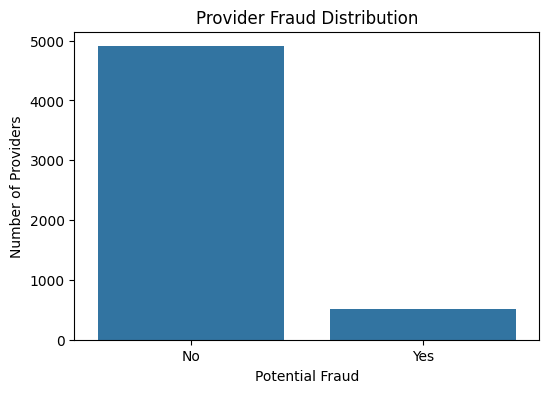

In [43]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="PotentialFraud"
)

plt.title("Provider Fraud Distribution")
plt.xlabel("Potential Fraud")
plt.ylabel("Number of Providers")

plt.show()

In [44]:
null_report = pd.DataFrame({
    "Null_Count": df.isna().sum(),
    "Null_Percentage": (
        df.isna().mean() * 100
    )
})

null_report = (
    null_report[
        null_report["Null_Count"] > 0
    ]
    .sort_values(
        "Null_Percentage",
        ascending=False
    )
)

display(null_report)

,Null_Count,Null_Percentage
IP_Unique_Procedure_Codes,3461,63.974122
IP_Avg_Deductible,3327,61.497227
IP_Unique_Beneficiaries,3318,61.330869
IP_Claim_Count,3318,61.330869
IP_Max_Reimbursement,3318,61.330869
IP_Total_Reimbursement,3318,61.330869
IP_Total_Deductible,3318,61.330869
IP_Avg_Claim_Duration,3318,61.330869
IP_Max_Claim_Duration,3318,61.330869
IP_Avg_Reimbursement,3318,61.330869


In [45]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

display(
    df[numeric_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Unique_Beneficiaries,5410.0,67.153420,142.748729,1.000000,8.000000,25.000000,65.000000,2.857000e+03
Avg_Patient_Age,5410.0,74.757406,4.555186,35.331964,72.945393,74.831749,76.612997,1.015825e+02
Avg_Chronic_Conditions,5410.0,4.425597,0.884788,0.000000,4.000000,4.375000,4.800000,1.000000e+01
IP_Claim_Count,2092.0,19.347036,34.983155,1.000000,3.000000,8.000000,19.000000,5.160000e+02
IP_Unique_Beneficiaries,2092.0,17.502868,30.703742,1.000000,3.000000,7.000000,17.000000,4.580000e+02
IP_Total_Reimbursement,2092.0,195170.659656,357963.082369,0.000000,29000.000000,77000.000000,188000.000000,5.580870e+06
IP_Avg_Reimbursement,2092.0,10208.098169,5139.034968,0.000000,7400.000000,9484.693085,11733.962441,5.700000e+04
IP_Max_Reimbursement,2092.0,30028.967495,21317.649565,0.000000,13000.000000,24000.000000,44000.000000,1.250000e+05
IP_Total_Deductible,2092.0,20203.680688,36553.781412,0.000000,3204.000000,8544.000000,19224.000000,5.361360e+05
IP_Avg_Deductible,2083.0,1068.000000,0.000000,1068.000000,1068.000000,1068.000000,1068.000000,1.068000e+03


In [46]:
negative_counts = (
    df[numeric_columns] < 0
).sum()

negative_counts = (
    negative_counts[
        negative_counts > 0
    ]
    .sort_values(ascending=False)
)

display(negative_counts)

Series([], dtype: int64)

In [47]:
X = df.drop(
    columns=[
        "Provider",
        "PotentialFraud"
    ]
).copy()

y = df["PotentialFraud"].map({
    "No": 0,
    "Yes": 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Feature shape: (5410, 30)
Target shape: (5410,)

Target values:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [48]:
print("Missing target values:", y.isna().sum())

print("\nTarget distribution:")
print(y.value_counts())

Missing target values: 0

Target distribution:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [ ]:
%pip install scikit-learn   

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nValidation target:")
print(y_val.value_counts())

Training data: (4328, 30)
Validation data: (1082, 30)

Training target:
PotentialFraud
0    3923
1     405
Name: count, dtype: int64

Validation target:
PotentialFraud
0    981
1    101
Name: count, dtype: int64


In [51]:


from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)



In [52]:
# Replace infinite values
X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_val = X_val.replace(
    [np.inf, -np.inf],
    np.nan
)

# Columns where missing means no observed activity
zero_fill_features = [
    col for col in [
        "IP_Claim_Count",
        "IP_Unique_Beneficiaries",
        "IP_Total_Reimbursement",
        "IP_Avg_Reimbursement",
        "IP_Max_Reimbursement",
        "IP_Total_Deductible",
        "IP_Avg_Deductible",
        "IP_Max_Claim_Duration",
        "IP_Avg_Claim_Duration",
        "IP_Unique_Diagnosis_Codes",
        "IP_Unique_Procedure_Codes",
        "OP_Claim_Count",
        "OP_Unique_Beneficiaries",
        "OP_Total_Reimbursement",
        "OP_Avg_Reimbursement",
        "OP_Max_Reimbursement",
        "OP_Total_Deductible",
        "OP_Avg_Deductible"
    ]
    if col in X_train.columns
]

# Fill activity-related missing values
for col in zero_fill_features:
    X_train[col] = X_train[col].fillna(0)
    X_val[col] = X_val[col].fillna(0)

# Remaining missing values → median
remaining = X_train.columns[
    X_train.isna().any()
]

if len(remaining) > 0:
    imputer = SimpleImputer(strategy="median")

    X_train[remaining] = imputer.fit_transform(
        X_train[remaining]
    )

    X_val[remaining] = imputer.transform(
        X_val[remaining]
    )

print(
    "Remaining training nulls:",
    X_train.isna().sum().sum()
)

print(
    "Remaining validation nulls:",
    X_val.isna().sum().sum()
)

Remaining training nulls: 0
Remaining validation nulls: 0


In [53]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

log_prob = log_model.predict_proba(
    X_val_scaled
)[:, 1]

log_pred = (
    log_prob >= 0.50
).astype(int)

print(
    classification_report(
        y_val,
        log_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_val, log_prob), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_val, log_prob), 4)
)

              precision    recall  f1-score   support

  Legitimate       0.99      0.90      0.94       981
       Fraud       0.49      0.91      0.63       101

    accuracy                           0.90      1082
   macro avg       0.74      0.91      0.79      1082
weighted avg       0.94      0.90      0.91      1082

ROC-AUC: 0.9724
PR-AUC: 0.7975


In [54]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_prob = rf_model.predict_proba(
    X_val
)[:, 1]

rf_pred = (
    rf_prob >= 0.50
).astype(int)

print(
    classification_report(
        y_val,
        rf_pred,
        target_names=["Legitimate", "Fraud"]
    )
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_val, rf_prob), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_val, rf_prob), 4)
)

              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.97       981
       Fraud       0.67      0.75      0.71       101

    accuracy                           0.94      1082
   macro avg       0.82      0.86      0.84      1082
weighted avg       0.95      0.94      0.94      1082

ROC-AUC: 0.9693
PR-AUC: 0.7822


In [55]:
gb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_prob = gb_model.predict_proba(
    X_val
)[:, 1]

gb_pred = (
    gb_prob >= 0.50
).astype(int)

In [56]:
results = []

for name, pred, prob in [
    ("Logistic Regression", log_pred, log_prob),
    ("Random Forest", rf_pred, rf_prob),
    ("Gradient Boosting", gb_pred, gb_prob)
]:

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "F1": f1_score(
            y_val, pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_val, prob
        ),
        "PR-AUC": average_precision_score(
            y_val, prob
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "PR-AUC",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Gradient Boosting,0.957486,0.839506,0.673267,0.747253,0.966603,0.818187
0,Logistic Regression,0.902033,0.486772,0.910891,0.634483,0.972406,0.797460
1,Random Forest,0.941774,0.666667,0.752475,0.706977,0.969278,0.782247


In [57]:
final_prob = rf_prob
prediction_results = pd.DataFrame({
    "Provider": df.loc[
        X_val.index,
        "Provider"
    ],
    "Fraud_Probability": final_prob
})

prediction_results["Fraud_Percentage"] = (
    prediction_results["Fraud_Probability"] * 100
)

prediction_results["Risk_Level"] = pd.cut(
    prediction_results["Fraud_Probability"],
    bins=[0, 0.30, 0.70, 1.0],
    labels=["LOW", "MEDIUM", "HIGH"],
    include_lowest=True
)

display(
    prediction_results
    .sort_values(
        "Fraud_Probability",
        ascending=False
    )
    .head(20)
)

,Provider,Fraud_Probability,Fraud_Percentage,Risk_Level
2616,PRV54258,0.993496,99.349610,HIGH
1596,PRV52985,0.993192,99.319159,HIGH
3346,PRV55194,0.992911,99.291066,HIGH
305,PRV51390,0.990172,99.017246,HIGH
3000,PRV54742,0.989455,98.945484,HIGH
1071,PRV52340,0.989402,98.940220,HIGH
2258,PRV53808,0.986557,98.655699,HIGH
3533,PRV55435,0.985836,98.583630,HIGH
1282,PRV52590,0.984936,98.493644,HIGH
4334,PRV56416,0.984879,98.487917,HIGH


In [58]:
thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:

    pred = (
        final_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "F1": f1_score(
            y_val, pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.20,0.449275,0.920792,0.603896
1,0.25,0.494444,0.881188,0.633452
2,0.30,0.537037,0.861386,0.661597
3,0.35,0.565517,0.811881,0.666667
4,0.40,0.591241,0.801980,0.680672
5,0.45,0.603175,0.752475,0.669604
6,0.50,0.666667,0.752475,0.706977
7,0.55,0.691589,0.732673,0.711538
8,0.60,0.771739,0.702970,0.735751
9,0.65,0.771084,0.633663,0.695652


In [59]:
import pickle
from pathlib import Path

MODEL_PATH = Path.cwd() / "fraud_model_gb.pkl"

with open(MODEL_PATH, "wb") as file:
    pickle.dump(gb_model, file)

print("Model saved successfully!")
print("Location:", MODEL_PATH)

Model saved successfully!
Location: c:\Users\Admin\Downloads\CTS_hackathon_demo\CTS_hackathon_demo\models\fraud_model_gb.pkl


In [60]:
import pickle
from pathlib import Path

# ============================================================
# MODEL A PICKLE
# ============================================================

MODEL_A_FILE = Path("fraud_model_gb.pkl")
print("=" * 80)
print("MODEL A PICKLE INSPECTION")
print("=" * 80)

print("File:", MODEL_A_FILE)
print("Exists:", MODEL_A_FILE.exists())

if not MODEL_A_FILE.exists():
    raise FileNotFoundError(
        f"Model A pickle not found:\n{MODEL_A_FILE}"
    )

# ------------------------------------------------------------
# Load pickle
# ------------------------------------------------------------

with open(MODEL_A_FILE, "rb") as f:
    model_a = pickle.load(f)

print("\nLoaded object:")
print(type(model_a))

print("\nModel representation:")
print(model_a)

# ------------------------------------------------------------
# Check common ML methods
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("AVAILABLE METHODS")
print("=" * 80)

methods = [
    "predict",
    "predict_proba",
    "decision_function",
    "transform",
    "fit",
    "get_params"
]

for method in methods:
    print(
        f"{method:20s}:",
        hasattr(model_a, method)
    )

# ------------------------------------------------------------
# Model parameters
# ------------------------------------------------------------

if hasattr(model_a, "get_params"):
    print("\n" + "=" * 80)
    print("MODEL PARAMETERS")
    print("=" * 80)

    params = model_a.get_params()

    for key, value in params.items():
        print(f"{key}: {value}")

# ------------------------------------------------------------
# Feature information if available
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE INFORMATION")
print("=" * 80)

for attr in [
    "n_features_in_",
    "feature_names_in_",
    "classes_"
]:
    if hasattr(model_a, attr):
        value = getattr(model_a, attr)

        print(f"\n{attr}:")
        print(value)

MODEL A PICKLE INSPECTION
File: fraud_model_gb.pkl
Exists: True

Loaded object:
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>

Model representation:
HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300,
                               random_state=42)

AVAILABLE METHODS
predict             : True
predict_proba       : True
decision_function   : True
transform           : False
fit                 : True
get_params          : True

MODEL PARAMETERS
categorical_features: warn
class_weight: None
early_stopping: auto
interaction_cst: None
l2_regularization: 0.0
learning_rate: 0.05
loss: log_loss
max_bins: 255
max_depth: None
max_features: 1.0
max_iter: 300
max_leaf_nodes: 31
min_samples_leaf: 20
monotonic_cst: None
n_iter_no_change: 10
random_state: 42
scoring: loss
tol: 1e-07
validation_fraction: 0.1
verbose: 0
warm_start: False

FEATURE INFORMATION

n_features_in_:
30

feature_names_in_:
['Unique_Beneficiaries' 'Avg_Patient_

In [61]:
gb_model.predict_proba(X)[:, 1]

array([9.32345488e-04, 9.80385114e-01, 9.25285619e-04, ...,
       5.68611474e-04, 9.39081580e-06, 2.00780703e-04], shape=(5410,))

In [62]:
fraud_class_index = list(model_a.classes_).index(1)

fraud_probability = model_a.predict_proba(X)[:, fraud_class_index]

fraud_risk_score = fraud_probability * 100

In [63]:
print("Number of predictions:", len(fraud_probability))
print("Minimum:", fraud_probability.min())
print("Maximum:", fraud_probability.max())
print("Mean:", fraud_probability.mean())

print("\nFraud probability distribution:")
print(
    pd.Series(fraud_probability).describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Number of predictions: 5410
Minimum: 3.533284232984034e-06
Maximum: 0.9999891845267639
Mean: 0.09122865354527057

Fraud probability distribution:
count    5410.000000
mean        0.091229
std         0.273844
min         0.000004
1%          0.000008
5%          0.000014
10%         0.000024
25%         0.000069
50%         0.000279
75%         0.002739
90%         0.082640
95%         0.970978
99%         0.999593
max         0.999989
dtype: float64


In [64]:
print("\nFirst 20 Model A probabilities:")
print(fraud_probability[:20])

print("\nFirst 20 Model A risk scores:")
print(fraud_risk_score[:20])


First 20 Model A probabilities:
[9.32345488e-04 9.80385114e-01 9.25285619e-04 2.37077380e-02
 1.58646605e-04 1.70957836e-03 6.85206350e-03 4.27485228e-04
 3.55119340e-03 4.06711082e-05 8.31900461e-04 9.54218485e-05
 1.00118873e-03 9.72339813e-01 9.33458825e-04 1.12577991e-04
 7.17342407e-03 8.21350549e-05 9.11349944e-05 1.65077504e-04]

First 20 Model A risk scores:
[9.32345488e-02 9.80385114e+01 9.25285619e-02 2.37077380e+00
 1.58646605e-02 1.70957836e-01 6.85206350e-01 4.27485228e-02
 3.55119340e-01 4.06711082e-03 8.31900461e-02 9.54218485e-03
 1.00118873e-01 9.72339813e+01 9.33458825e-02 1.12577991e-02
 7.17342407e-01 8.21350549e-03 9.11349944e-03 1.65077504e-02]


In [65]:
print("=" * 80)
print("MODEL A INPUT VALIDATION")
print("=" * 80)

print("X shape:", X.shape)

print("\nExpected feature count:", model_a.n_features_in_)
print("Actual feature count:", X.shape[1])

print("\nFeature names:")
print(list(X.columns))

print("\nDuplicate rows:", X.duplicated().sum())

print("\nMissing values:")
print(X.isna().sum().sum())

print("\nInfinite values:")
print(np.isinf(X.select_dtypes(include=[np.number])).sum().sum())

MODEL A INPUT VALIDATION
X shape: (5410, 30)

Expected feature count: 30
Actual feature count: 30

Feature names:
['Unique_Beneficiaries', 'Avg_Patient_Age', 'Avg_Chronic_Conditions', 'IP_Claim_Count', 'IP_Unique_Beneficiaries', 'IP_Total_Reimbursement', 'IP_Avg_Reimbursement', 'IP_Max_Reimbursement', 'IP_Total_Deductible', 'IP_Avg_Deductible', 'IP_Avg_Claim_Duration', 'IP_Max_Claim_Duration', 'IP_Unique_Diagnosis_Codes', 'IP_Unique_Procedure_Codes', 'OP_Claim_Count', 'OP_Unique_Beneficiaries', 'OP_Total_Reimbursement', 'OP_Avg_Reimbursement', 'OP_Max_Reimbursement', 'OP_Total_Deductible', 'OP_Avg_Deductible', 'Total_Claims', 'Total_Reimbursement', 'Total_Deductible', 'Claims_Per_Beneficiary', 'Reimbursement_Per_Beneficiary', 'IP_Claim_Share', 'OP_Claim_Share', 'IP_Reimbursement_Range', 'OP_Reimbursement_Range']

Duplicate rows: 0

Missing values:
39436

Infinite values:
0


In [72]:
print("=" * 80)
print("MODEL A INPUT VALIDATION")
print("=" * 80)

print("X shape:", X.shape)
print("Expected feature count:", model_a.n_features_in_)
print("Actual feature count:", X.shape[1])

# ============================================================
# FEATURE CHECK
# ============================================================

if hasattr(model_a, "feature_names_in_"):
    expected_features = list(model_a.feature_names_in_)
else:
    expected_features = []

print("\nFeature names match:")

if expected_features:
    print(
        set(expected_features) == set(X.columns)
    )

    missing = [
        c for c in expected_features
        if c not in X.columns
    ]

    extra = [
        c for c in X.columns
        if c not in expected_features
    ]

    print("Missing:", missing)
    print("Extra:", extra)

# ============================================================
# DATA QUALITY
# ============================================================

print("\nDuplicate rows:", X.duplicated().sum())

print(
    "Missing values:",
    X.isna().sum().sum()
)

numeric_X = X.select_dtypes(include=[np.number])

print(
    "Infinite values:",
    np.isinf(numeric_X).sum().sum()
)

# ============================================================
# FIND PROVIDER IDENTIFIER IN SOURCE DATAFRAME
# ============================================================

print("\n" + "=" * 80)
print("PROVIDER IDENTIFIER SEARCH")
print("=" * 80)

print("Source dataframe:", type(df))
print("Source shape:", df.shape)

possible_provider_columns = [
    "Provider",
    "PRVDR_NUM",
    "primary_provider_npi",
    "PROVIDER",
    "PROVIDER_ID",
    "provider",
    "provider_id"
]

found = []

for col in possible_provider_columns:
    if col in df.columns:
        found.append(col)

print("\nProvider columns found:")

if found:
    for col in found:
        print(
            f"{col}: "
            f"{df[col].nunique(dropna=True):,} unique values"
        )
else:
    print("NONE")

# ============================================================
# SHOW ALL COLUMNS CONTAINING PROVIDER
# ============================================================

provider_like = [
    c for c in df.columns
    if "provider" in str(c).lower()
    or "prvdr" in str(c).lower()
]

print("\nProvider-like columns:")
print(provider_like)

MODEL A INPUT VALIDATION
X shape: (5410, 30)
Expected feature count: 30
Actual feature count: 30

Feature names match:
True
Missing: []
Extra: []

Duplicate rows: 0
Missing values: 39436
Infinite values: 0

PROVIDER IDENTIFIER SEARCH
Source dataframe: <class 'pandas.core.frame.DataFrame'>
Source shape: (5410, 32)

Provider columns found:
Provider: 5,410 unique values

Provider-like columns:
['Provider']


In [73]:
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# ============================================================
# MODEL A PRODUCTION ARTIFACT
# ============================================================

MODEL_DIR = Path("../models/model_a")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = MODEL_DIR / "fraud_model_gb.pkl"
IMPUTER_FILE = MODEL_DIR / "fraud_model_imputer.pkl"
SCHEMA_FILE = MODEL_DIR / "feature_schema.json"
PROVIDER_SCORE_FILE = MODEL_DIR / "provider_fraud_scores.csv"

print("=" * 80)
print("BUILDING MODEL A PRODUCTION ARTIFACT")
print("=" * 80)

# ============================================================
# 1. VERIFY MODEL
# ============================================================

print("\nModel:")
print(type(model_a))

print("Expected features:", model_a.n_features_in_)
print("Actual features:", X.shape[1])

if model_a.n_features_in_ != X.shape[1]:
    raise ValueError("Model feature count does not match X.")

# ============================================================
# 2. FEATURE SCHEMA
# ============================================================

feature_names = list(X.columns)

print("\nFeature count:", len(feature_names))
print("Feature names:")
for i, col in enumerate(feature_names, start=1):
    print(f"{i:02d}. {col}")

# ============================================================
# 3. CREATE IMPUTER
# ============================================================

# Work on numeric Model A features only.
X_numeric = X.copy()

for col in X_numeric.columns:
    X_numeric[col] = pd.to_numeric(
        X_numeric[col],
        errors="coerce"
    )

# Median imputation.
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X_numeric)

print("\nOriginal missing values:", int(X_numeric.isna().sum().sum()))
print("Missing after imputation:", int(np.isnan(X_imputed).sum()))

# ============================================================
# 4. SAVE IMPUTER
# ============================================================

with open(IMPUTER_FILE, "wb") as f:
    pickle.dump(imputer, f)

print("\nSaved imputer:")
print(IMPUTER_FILE)

# ============================================================
# 5. SAVE FEATURE SCHEMA
# ============================================================

schema = {
    "model_name": "Model A - HistGradientBoosting Fraud Model",
    "model_type": type(model_a).__name__,
    "feature_count": len(feature_names),
    "features": feature_names,
    "identifier": "Provider",
    "target_classes": [0, 1],
    "fraud_class": 1,
    "preprocessing": {
        "numeric_conversion": True,
        "imputation": "median",
        "scaling": False
    }
}

with open(SCHEMA_FILE, "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=4)

print("Saved schema:")
print(SCHEMA_FILE)

# ============================================================
# 6. GENERATE PROVIDER FRAUD SCORES
# ============================================================

fraud_class_index = list(model_a.classes_).index(1)

fraud_probability = model_a.predict_proba(
    X_imputed
)[:, fraud_class_index]

fraud_risk_score = fraud_probability * 100

# Provider column must come from the original source dataframe.
if "Provider" not in df.columns:
    raise ValueError(
        "Provider column not found in source dataframe."
    )

if len(df) != len(X):
    raise ValueError(
        "Provider rows and feature rows do not match."
    )

provider_scores = pd.DataFrame({
    "Provider": df["Provider"].astype(str).values,
    "FRAUD_PROBABILITY": fraud_probability,
    "FRAUD_RISK_SCORE": fraud_risk_score
})

# ============================================================
# 7. VALIDATE PROVIDER SCORES
# ============================================================

if provider_scores["Provider"].duplicated().any():
    raise ValueError(
        "Duplicate Provider values found."
    )

if provider_scores["FRAUD_PROBABILITY"].isna().any():
    raise ValueError(
        "Missing fraud probabilities."
    )

if provider_scores["FRAUD_RISK_SCORE"].isna().any():
    raise ValueError(
        "Missing fraud risk scores."
    )

if (
    (provider_scores["FRAUD_RISK_SCORE"] < 0).any()
    or
    (provider_scores["FRAUD_RISK_SCORE"] > 100).any()
):
    raise ValueError(
        "Fraud risk score outside 0-100."
    )

# ============================================================
# 8. SAVE PROVIDER SCORE TABLE
# ============================================================

provider_scores.to_csv(
    PROVIDER_SCORE_FILE,
    index=False
)

print("\nSaved provider fraud scores:")
print(PROVIDER_SCORE_FILE)

# ============================================================
# 9. SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("MODEL A PRODUCTION ARTIFACT COMPLETE")
print("=" * 80)

print("Providers:", len(provider_scores))
print("Features:", len(feature_names))

print(
    "Fraud probability min:",
    provider_scores["FRAUD_PROBABILITY"].min()
)

print(
    "Fraud probability max:",
    provider_scores["FRAUD_PROBABILITY"].max()
)

print(
    "Fraud probability mean:",
    provider_scores["FRAUD_PROBABILITY"].mean()
)

print(
    "Fraud risk score min:",
    provider_scores["FRAUD_RISK_SCORE"].min()
)

print(
    "Fraud risk score max:",
    provider_scores["FRAUD_RISK_SCORE"].max()
)

print("\nArtifacts:")
print("  Model   :", MODEL_FILE)
print("  Imputer :", IMPUTER_FILE)
print("  Schema  :", SCHEMA_FILE)
print("  Scores  :", PROVIDER_SCORE_FILE)

BUILDING MODEL A PRODUCTION ARTIFACT

Model:
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>
Expected features: 30
Actual features: 30

Feature count: 30
Feature names:
01. Unique_Beneficiaries
02. Avg_Patient_Age
03. Avg_Chronic_Conditions
04. IP_Claim_Count
05. IP_Unique_Beneficiaries
06. IP_Total_Reimbursement
07. IP_Avg_Reimbursement
08. IP_Max_Reimbursement
09. IP_Total_Deductible
10. IP_Avg_Deductible
11. IP_Avg_Claim_Duration
12. IP_Max_Claim_Duration
13. IP_Unique_Diagnosis_Codes
14. IP_Unique_Procedure_Codes
15. OP_Claim_Count
16. OP_Unique_Beneficiaries
17. OP_Total_Reimbursement
18. OP_Avg_Reimbursement
19. OP_Max_Reimbursement
20. OP_Total_Deductible
21. OP_Avg_Deductible
22. Total_Claims
23. Total_Reimbursement
24. Total_Deductible
25. Claims_Per_Beneficiary
26. Reimbursement_Per_Beneficiary
27. IP_Claim_Share
28. OP_Claim_Share
29. IP_Reimbursement_Range
30. OP_Reimbursement_Range

Original missing values: 39436
Missing 

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [74]:
import pickle
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer


# ============================================================
# MODEL A — PRODUCTION PREPROCESSOR
# ============================================================

MODEL_DIR = Path("../models/model_a")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = "fraud_model_gb.pkl"
PREPROCESSOR_FILE = MODEL_DIR / "fraud_model_preprocessor.pkl"
SCHEMA_FILE = MODEL_DIR / "feature_schema.json"


# ============================================================
# 1. LOAD TRAINED MODEL
# ============================================================

with open(MODEL_FILE, "rb") as f:
    model_a = pickle.load(f)

print("Model loaded:")
print(type(model_a))


# ============================================================
# 2. DEFINE EXACT MODEL FEATURES
# ============================================================

FEATURES = [
    "Unique_Beneficiaries",
    "Avg_Patient_Age",
    "Avg_Chronic_Conditions",
    "IP_Claim_Count",
    "IP_Unique_Beneficiaries",
    "IP_Total_Reimbursement",
    "IP_Avg_Reimbursement",
    "IP_Max_Reimbursement",
    "IP_Total_Deductible",
    "IP_Avg_Deductible",
    "IP_Avg_Claim_Duration",
    "IP_Max_Claim_Duration",
    "IP_Unique_Diagnosis_Codes",
    "IP_Unique_Procedure_Codes",
    "OP_Claim_Count",
    "OP_Unique_Beneficiaries",
    "OP_Total_Reimbursement",
    "OP_Avg_Reimbursement",
    "OP_Max_Reimbursement",
    "OP_Total_Deductible",
    "OP_Avg_Deductible",
    "Total_Claims",
    "Total_Reimbursement",
    "Total_Deductible",
    "Claims_Per_Beneficiary",
    "Reimbursement_Per_Beneficiary",
    "IP_Claim_Share",
    "OP_Claim_Share",
    "IP_Reimbursement_Range",
    "OP_Reimbursement_Range"
]

print("\nFeature count:", len(FEATURES))
print("Model feature count:", model_a.n_features_in_)

if model_a.n_features_in_ != len(FEATURES):
    raise ValueError("Feature count mismatch.")


# ============================================================
# 3. ACTIVITY FEATURES
#    EXACTLY AS USED DURING MODEL TRAINING
# ============================================================

ZERO_FILL_FEATURES = [
    "IP_Claim_Count",
    "IP_Unique_Beneficiaries",
    "IP_Total_Reimbursement",
    "IP_Avg_Reimbursement",
    "IP_Max_Reimbursement",
    "IP_Total_Deductible",
    "IP_Avg_Deductible",
    "IP_Max_Claim_Duration",
    "IP_Avg_Claim_Duration",
    "IP_Unique_Diagnosis_Codes",
    "IP_Unique_Procedure_Codes",
    "OP_Claim_Count",
    "OP_Unique_Beneficiaries",
    "OP_Total_Reimbursement",
    "OP_Avg_Reimbursement",
    "OP_Max_Reimbursement",
    "OP_Total_Deductible",
    "OP_Avg_Deductible"
]

ZERO_FILL_FEATURES = [
    c for c in ZERO_FILL_FEATURES
    if c in FEATURES
]


# ============================================================
# 4. PREPARE THE SAME DATA USED FOR MODEL TRAINING
#
# X_train must still exist from your original training notebook.
# ============================================================

X_train_model_a = X_train[FEATURES].copy()

# Convert everything to numeric
for col in FEATURES:
    X_train_model_a[col] = pd.to_numeric(
        X_train_model_a[col],
        errors="coerce"
    )

# Replace infinity
X_train_model_a = X_train_model_a.replace(
    [np.inf, -np.inf],
    np.nan
)

# Activity-related missing values → 0
for col in ZERO_FILL_FEATURES:
    X_train_model_a[col] = (
        X_train_model_a[col].fillna(0)
    )


# ============================================================
# 5. FIND REMAINING FEATURES REQUIRING MEDIAN IMPUTATION
# ============================================================

MEDIAN_FEATURES = [
    col
    for col in FEATURES
    if X_train_model_a[col].isna().any()
]

print("\nFeatures using median imputation:")
print(MEDIAN_FEATURES)


# ============================================================
# 6. FIT MEDIAN IMPUTER ON TRAINING DATA ONLY
# ============================================================

if len(MEDIAN_FEATURES) > 0:

    median_imputer = SimpleImputer(
        strategy="median"
    )

    median_imputer.fit(
        X_train_model_a[MEDIAN_FEATURES]
    )

else:
    median_imputer = None


# ============================================================
# 7. SAVE COMPLETE PREPROCESSOR
# ============================================================

preprocessor = {
    "feature_names": FEATURES,
    "zero_fill_features": ZERO_FILL_FEATURES,
    "median_features": MEDIAN_FEATURES,
    "median_imputer": median_imputer,
    "replace_infinite": True,
    "numeric_conversion": True
}

with open(PREPROCESSOR_FILE, "wb") as f:
    pickle.dump(preprocessor, f)

print("\nSaved production preprocessor:")
print(PREPROCESSOR_FILE)


# ============================================================
# 8. SAVE / UPDATE SCHEMA
# ============================================================

schema = {
    "model_name": "Model A - Provider Fraud Detection",
    "model_type": type(model_a).__name__,
    "feature_count": len(FEATURES),
    "features": FEATURES,
    "identifier": "Provider",
    "fraud_class": 1,
    "preprocessing": {
        "numeric_conversion": True,
        "replace_infinite_with_nan": True,
        "zero_fill_features": ZERO_FILL_FEATURES,
        "remaining_missing": "median",
        "median_fitted_on": "training_data_only",
        "scaling": False
    }
}

with open(SCHEMA_FILE, "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=4)

print("Updated schema:")
print(SCHEMA_FILE)


# ============================================================
# 9. VALIDATE
# ============================================================

print("\n" + "=" * 80)
print("MODEL A PREPROCESSOR COMPLETE")
print("=" * 80)

print("Features:", len(FEATURES))
print("Zero-fill features:", len(ZERO_FILL_FEATURES))
print("Median-imputed features:", len(MEDIAN_FEATURES))
print("Scaling:", False)
print("Training-only median:", True)

print("\nArtifacts:")
print("Model       :", MODEL_FILE)
print("Preprocessor:", PREPROCESSOR_FILE)
print("Schema      :", SCHEMA_FILE)

Model loaded:
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>

Feature count: 30
Model feature count: 30

Features using median imputation:
[]

Saved production preprocessor:
..\models\model_a\fraud_model_preprocessor.pkl
Updated schema:
..\models\model_a\feature_schema.json

MODEL A PREPROCESSOR COMPLETE
Features: 30
Zero-fill features: 18
Median-imputed features: 0
Scaling: False
Training-only median: True

Artifacts:
Model       : fraud_model_gb.pkl
Preprocessor: ..\models\model_a\fraud_model_preprocessor.pkl
Schema      : ..\models\model_a\feature_schema.json


In [75]:
# ============================================================
# MODEL A — PRODUCTION INFERENCE TEST
# ============================================================

import pickle
import numpy as np
import pandas as pd

with open(MODEL_FILE, "rb") as f:
    model_a = pickle.load(f)

with open(PREPROCESSOR_FILE, "rb") as f:
    preprocessor = pickle.load(f)


def preprocess_model_a_input(data):
    """
    Apply exactly the preprocessing used during Model A training.
    """

    X_input = data[
        preprocessor["feature_names"]
    ].copy()

    # Numeric conversion
    for col in X_input.columns:
        X_input[col] = pd.to_numeric(
            X_input[col],
            errors="coerce"
        )

    # Infinity → NaN
    X_input = X_input.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Activity missing → 0
    for col in preprocessor["zero_fill_features"]:
        X_input[col] = X_input[col].fillna(0)

    # Remaining missing → training medians
    median_features = preprocessor["median_features"]

    if (
        median_features
        and
        preprocessor["median_imputer"] is not None
    ):
        X_input[median_features] = (
            preprocessor["median_imputer"]
            .transform(
                X_input[median_features]
            )
        )

    return X_input


# ------------------------------------------------------------
# TEST USING EXISTING DATA
# ------------------------------------------------------------

X_test = X.copy()

X_processed = preprocess_model_a_input(
    X_test
)

print("Original shape:", X_test.shape)
print("Processed shape:", X_processed.shape)

print(
    "Remaining missing:",
    X_processed.isna().sum().sum()
)

print(
    "Remaining infinite:",
    np.isinf(
        X_processed.select_dtypes(
            include=[np.number]
        )
    ).sum().sum()
)


# ------------------------------------------------------------
# PREDICT
# ------------------------------------------------------------

fraud_class_index = list(
    model_a.classes_
).index(1)

fraud_probability = model_a.predict_proba(
    X_processed
)[:, fraud_class_index]

fraud_risk_score = (
    fraud_probability * 100
)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

model_a_test_results = pd.DataFrame({
    "FRAUD_PROBABILITY": fraud_probability,
    "FRAUD_RISK_SCORE": fraud_risk_score
})

print("\n" + "=" * 80)
print("MODEL A INFERENCE TEST")
print("=" * 80)

print(
    "Predictions:",
    len(model_a_test_results)
)

print(
    "Probability min:",
    fraud_probability.min()
)

print(
    "Probability max:",
    fraud_probability.max()
)

print(
    "Probability mean:",
    fraud_probability.mean()
)

print(
    "Risk score min:",
    fraud_risk_score.min()
)

print(
    "Risk score max:",
    fraud_risk_score.max()
)

display(
    model_a_test_results.head(20)
)

Original shape: (5410, 30)
Processed shape: (5410, 30)
Remaining missing: 0
Remaining infinite: 0

MODEL A INFERENCE TEST
Predictions: 5410
Probability min: 3.533284232984034e-06
Probability max: 0.9999891845267639
Probability mean: 0.09145274057830784
Risk score min: 0.00035332842329840336
Risk score max: 99.99891845267639


,FRAUD_PROBABILITY,FRAUD_RISK_SCORE
0,0.000932,0.093235
1,0.980385,98.038511
2,0.001253,0.125306
3,0.017764,1.776364
4,0.000159,0.015865
5,0.001710,0.170958
6,0.006852,0.685206
7,0.000427,0.042749
8,0.003551,0.355119
9,0.000041,0.004067
